# 06. Data Quality Controls
**Engineering Data Processing with Python** | one-day course | about 35 minutes

> **TRAINER / SOLUTION VERSION.** Every blank is filled in and the notebook has been run.


In [1]:
# @title Setup: run this cell first (it loads the course data)
# ===================== SETUP: run this cell first (click it, then Shift+Enter) =====================
# It makes sure the course data is available in this Colab session and loads the tools we need.
import os, zipfile, urllib.request
from pathlib import Path

DATA_ZIP_URL = "https://raw.githubusercontent.com/buildyourai/ei-python-data-processing/main/data.zip"   # course data (fictional / public)

def get_course_data():
    if Path("data").is_dir():
        print("Data folder found:", sorted(p.name for p in Path("data").iterdir())[:20])
        return
    if not Path("data.zip").exists() and DATA_ZIP_URL:
        print("Downloading course data...")
        urllib.request.urlretrieve(DATA_ZIP_URL, "data.zip")
    zip_path = Path("data.zip")
    if not zip_path.exists():
        try:
            from google.colab import files
            print("Choose data.zip from your computer (your trainer will tell you where it is).")
            uploaded = files.upload()
            zip_path = Path(next(iter(uploaded)))
        except ImportError:
            raise FileNotFoundError("Put data.zip or the data folder next to this notebook.")
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(".")
    print("Data ready:", sorted(p.name for p in Path("data").iterdir()))

get_course_data()
Path("outputs").mkdir(exist_ok=True)

import pandas as pd
import numpy as np
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)

def check(condition, ok="Looks right.", hint="Not quite yet. Re-read the instructions above the cell."):
    """Tiny self-check helper used throughout the course."""
    print(("PASS: " + ok) if condition else ("NOT YET: " + hint))

Data folder found: ['3dprinter.csv', 'asset_register.xlsx', 'boiler.json', 'capstone', 'checkpoints', 'concrete.csv', 'manifest.TXT', 'manifest.csv', 'sensor_readings.csv', 'steel.csv', 'thermal-profiles.xlsx', 'work_orders_cmms.csv', 'work_orders_legacy.xlsx']


## The point of this module

Cleaning fixes the problems you know about. Quality checks catch the ones you didn't expect, every time new data
arrives. You will:

1. Write simple rules that flag bad rows.
2. Separate **errors** (leave out of the figures) from **warnings** (report, but keep).
3. Check sensor data for "no reading" codes, mixed units and stuck sensors.
4. See whether the sensor data warned of a real breakdown.

In [2]:
DATES = ["date_raised", "date_closed", "last_modified"]
wo = pd.read_csv("data/checkpoints/m05_work_orders_combined.csv", parse_dates=DATES)
print(wo.shape)

(1366, 22)


## 1. Rules that flag bad rows

Each rule is a question asked of every row, with a True/False answer. **True means a problem.**
Example: a job cannot be closed before it was raised.

In [3]:
closed_before_raised = wo["date_closed"] < wo["date_raised"]
print("Rows flagged:", closed_before_raised.sum())
wo.loc[closed_before_raised, ["wo_id", "date_raised", "date_closed"]]

Rows flagged: 6


,wo_id,date_raised,date_closed
69,WO-25-00070,2025-02-16 17:50:00,2025-02-01 17:50:00
144,WO-25-00145,2025-03-31 16:05:00,2025-03-06 16:05:00
377,WO-25-00378,2025-08-31 13:10:00,2025-08-12 13:10:00
532,WO-25-00533,2025-11-28 18:10:00,2025-11-26 18:10:00
853,WO-26-00854,2026-06-08 15:50:00,2026-05-12 15:50:00
887,WO-26-00888,2026-07-01 13:05:00,2026-06-14 13:05:00


### Your turn 6.1
Three more rules in the same style. Fill in:
* labour hours below **0**
* labour hours above **80** (longer than any single job Kilbrack would expect)
* asset status equal to **"Unknown asset"**

In [4]:
rules = {
    "closed_before_raised": wo["date_closed"] < wo["date_raised"],
    "negative_hours":       wo["labour_hours"] < 0,
    "implausible_hours":    wo["labour_hours"] > 80,
    "unknown_asset":        wo["asset_status"] == "Unknown asset",
    "closed_without_date":  (wo["status"] == "Closed") & wo["date_closed"].isna(),
    "missing_cost":         wo["parts_cost_eur"].isna(),
    "negative_cost":        wo["parts_cost_eur"] < 0,
}
for name, flagged in rules.items():
    print(f"{name:22} {flagged.sum():4d} rows")

closed_before_raised      6 rows
negative_hours            4 rows
implausible_hours         3 rows
unknown_asset             6 rows
closed_without_date       5 rows
missing_cost             88 rows
negative_cost             1 rows


In [5]:
check(rules["negative_hours"].sum() == 4 and rules["implausible_hours"].sum() == 3 and rules["unknown_asset"].sum() == 6,
      "Rules are catching the planted problems.", "Check the numbers and the spelling of 'Unknown asset'.")

PASS: Rules are catching the planted problems.


Why 80 hours? It's a judgement. Write thresholds down as named settings so anyone can see and challenge them.

## 2. Errors versus warnings

* **Error:** the row is wrong and would distort the figures. Leave it out and send it back to be fixed.
* **Warning:** worth knowing, but the row is still usable. A missing cost doesn't stop you counting jobs.

Run and read:

In [6]:
ERRORS = ["closed_before_raised", "negative_hours", "implausible_hours", "unknown_asset", "closed_without_date"]

flags = pd.DataFrame(rules)
wo["dq_issues"] = flags.apply(lambda row: ", ".join(row.index[row]), axis=1)   # list the problems on each row
wo["dq_error"] = flags[ERRORS].any(axis=1)                                     # True if any ERROR rule fired

report = pd.DataFrame({"rule": flags.columns,
                       "severity": ["error" if r in ERRORS else "warning" for r in flags.columns],
                       "rows_flagged": flags.sum().values})
report

,rule,severity,rows_flagged
0,closed_before_raised,error,6
1,negative_hours,error,4
2,implausible_hours,error,3
3,unknown_asset,error,6
4,closed_without_date,error,5
5,missing_cost,warning,88
6,negative_cost,warning,1


In [7]:
kpi_ready = wo[~wo["dq_error"]]          # ~ means "not": keep rows WITHOUT errors
print(len(wo), "rows ->", len(kpi_ready), "rows safe for KPIs")

report.to_csv("outputs/dq_report.csv", index=False)
wo[wo["dq_issues"] != ""].to_csv("outputs/dq_issues.csv", index=False)
kpi_ready.to_csv("outputs/work_orders_kpi_ready.csv", index=False)
wo.loc[wo["dq_error"], ["wo_id", "asset_id", "labour_hours", "dq_issues"]].head(8)

1366 rows -> 1342 rows safe for KPIs


,wo_id,asset_id,labour_hours,dq_issues
35,WO-25-00035,CNV-021,1.0,unknown_asset
69,WO-25-00070,CNC-007,4.5,closed_before_raised
144,WO-25-00145,HYP-001,NaN,"closed_before_raised, missing_cost"
154,WO-25-00155,PMP-020,1.5,unknown_asset
294,WO-25-00295,PMP-001,240.0,implausible_hours
326,WO-25-00327,PMP-001,-2.5,negative_hours
362,WO-25-00363,PMP-006,1.5,closed_without_date
377,WO-25-00378,PMP-005,5.0,"closed_before_raised, missing_cost"


## 3. Hard stops

Some problems mean the whole run can't be trusted: duplicate IDs, dates that failed to load. For those, the code
should **stop** with a clear message. `assert` does that: nothing happens if the statement is true; it stops with
your message if it's false.

In [8]:
assert wo["wo_id"].is_unique, "Duplicate work order IDs: the dedup step failed"
assert wo["date_raised"].notna().all(), "Some work orders have no raised date"
print("Hard checks passed.")

Hard checks passed.


Rule of thumb: **stop** for problems with the whole table, **flag** problems with individual rows.

## 4. Sensor data

Readings every 10 minutes from three compressors and three pumps, 1 to 21 August 2026.

In [9]:
sens = pd.read_csv("data/sensor_readings.csv", parse_dates=["timestamp"])
sens.describe().round(1)

,timestamp,bearing_temp,vibration_mm_s,discharge_pressure
count,18148,18148.0,18148.0,18058.0
mean,2026-08-11 11:45:41.657483008,67.7,9.1,61.5
min,2026-08-01 00:00:00,-999.0,0.0,0.0
25%,2026-08-06 06:00:00,54.4,2.1,3.5
50%,2026-08-11 11:50:00,60.1,2.3,7.4
75%,2026-08-16 17:50:00,63.9,2.6,7.6
max,2026-08-21 23:50:00,153.4,9999.0,378.3
std,NaN,66.0,257.0,124.8


A temperature of **-999** and a vibration of **9999**. These are the logger's codes for "no reading". Left in, they
wreck every average and trigger every alarm.

### Your turn 6.2
Replace both codes with "missing" (`np.nan`). Fill in the two code values.

In [10]:
for col in ["bearing_temp", "vibration_mm_s", "discharge_pressure"]:
    sens[col] = sens[col].replace([-999, 9999], np.nan)
sens.describe().round(1)

,timestamp,bearing_temp,vibration_mm_s,discharge_pressure
count,18148,18093.0,18136.0,18058.0
mean,2026-08-11 11:45:41.657483008,70.9,2.5,61.5
min,2026-08-01 00:00:00,21.1,0.0,0.0
25%,2026-08-06 06:00:00,54.5,2.1,3.5
50%,2026-08-11 11:50:00,60.1,2.3,7.4
75%,2026-08-16 17:50:00,64.0,2.6,7.6
max,2026-08-21 23:50:00,153.4,16.4,378.3
std,NaN,30.1,1.0,124.8


In [11]:
check(sens["bearing_temp"].min() > -100 and sens["vibration_mm_s"].max() < 100, "No-reading codes gone.",
      "Check the two values.")

PASS: No-reading codes gone.


**Mixed units.** One logger reports temperature in °F, another reports pressure in kPa. Look at each asset's typical
temperature:

In [12]:
sens.groupby("asset_id")[["bearing_temp", "discharge_pressure"]].median().round(1)

,bearing_temp,discharge_pressure
asset_id,,
CMP-001,59.0,7.5
CMP-002,58.0,7.5
CMP-003,136.4,7.5
PMP-001,58.1,3.4
PMP-002,57.9,3.4
PMP-004,57.9,339.8


CMP-003 runs at about 136 "degrees" and PMP-004 at 340 "bar"? No. Those are °F and kPa. The fix only changes the
rows with the odd unit. Run and read.

In [13]:
f_rows = sens["temp_unit"] == "F"
sens.loc[f_rows, "bearing_temp"] = (sens.loc[f_rows, "bearing_temp"] - 32) * 5 / 9
sens.loc[f_rows, "temp_unit"] = "C"

kpa_rows = sens["pressure_unit"] == "kPa"
sens.loc[kpa_rows, "discharge_pressure"] = sens.loc[kpa_rows, "discharge_pressure"] / 100
sens.loc[kpa_rows, "pressure_unit"] = "bar"

sens = sens.drop_duplicates(subset=["timestamp", "asset_id"])        # the logger re-sent some readings
sens.groupby("asset_id")[["bearing_temp", "discharge_pressure"]].median().round(1)

,bearing_temp,discharge_pressure
asset_id,,
CMP-001,59.0,7.5
CMP-002,58.0,7.5
CMP-003,58.0,7.5
PMP-001,57.9,3.4
PMP-002,57.9,3.4
PMP-004,57.9,3.4


Every bearing now runs at a believable 58 to 59 °C, and the three pumps show the same pressure. That engineering sense check is worth more than any code check.

## 5. Stuck sensors and alarms

The helper adds three flags. Just run it.

| Flag | Rule | Catches |
|---|---|---|
| `spike` | One reading far from its neighbours | Electrical noise, bad readings |
| `stuck` | Exactly the same value for an hour while the machine runs | A frozen sensor |
| `alarm` | Vibration above the alarm level (and not a spike) | Real machine problems |

In [14]:
# @title Helper: add_flags(sensor_table, alarm_level) (just run it)
def add_flags(sens, alarm_level):
    sens = sens.sort_values(["asset_id", "timestamp"]).copy()
    g = sens.groupby("asset_id")["vibration_mm_s"]
    median_nearby = g.transform(lambda x: x.rolling(7, center=True, min_periods=3).median())
    spread_last_hour = g.transform(lambda x: x.rolling(6).std())
    sens["spike"] = (sens["vibration_mm_s"] - median_nearby).abs() > 5
    sens["stuck"] = (spread_last_hour == 0) & (sens["vibration_mm_s"] > 0.5)
    sens["alarm"] = (sens["vibration_mm_s"] > alarm_level) & ~sens["spike"]
    return sens
print("add_flags() is ready")

add_flags() is ready


In [15]:
flagged = add_flags(sens, alarm_level=7.1)      # 7.1 mm/s: an illustrative alarm level for today
flagged.groupby("asset_id")[["spike", "stuck", "alarm"]].sum()

,spike,stuck,alarm
asset_id,,,
CMP-001,0,0,311
CMP-002,0,0,0
CMP-003,0,0,0
PMP-001,3,0,0
PMP-002,0,43,0
PMP-004,3,0,0


PMP-002 has a stuck sensor: a data problem, not a machine problem. Only CMP-001 has real alarms. Keep the two kinds
of flag separate: you don't want a frozen sensor raising a work order, or a real alarm being filtered out as noise.

## 6. Did the data see the breakdown coming?

The CMMS has a breakdown work order on **CMP-001** raised 18 Aug 2026 at 14:20: *bearing failure*.

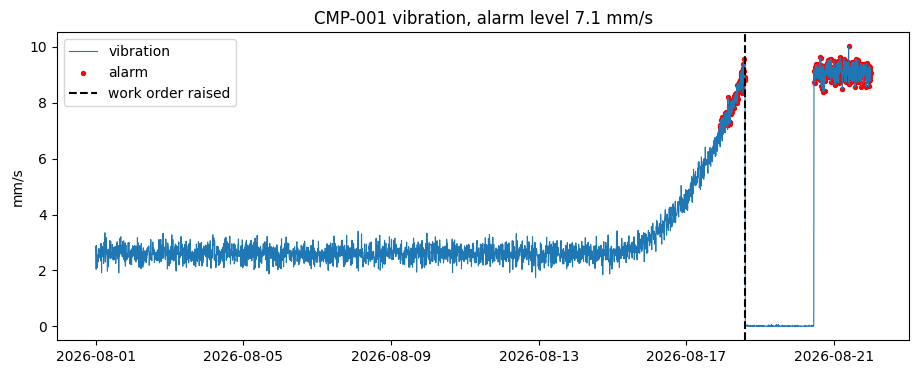

First alarm: 2026-08-17 21:40:00  ->  17 hours before the work order


In [16]:
import matplotlib.pyplot as plt
WO_RAISED = pd.Timestamp("2026-08-18 14:20")

def plot_cmp001(flagged, alarm_level):
    c = flagged[flagged["asset_id"] == "CMP-001"]
    plt.figure(figsize=(11, 4))
    plt.plot(c["timestamp"], c["vibration_mm_s"], lw=0.8, label="vibration")
    plt.scatter(c.loc[c["alarm"], "timestamp"], c.loc[c["alarm"], "vibration_mm_s"], color="red", s=8, label="alarm")
    plt.axvline(WO_RAISED, color="black", ls="--", label="work order raised")
    plt.ylabel("mm/s"); plt.legend(loc="upper left"); plt.title(f"CMP-001 vibration, alarm level {alarm_level} mm/s")
    plt.show()
    first = c.loc[c["alarm"], "timestamp"].min()
    print(f"First alarm: {first}  ->  {(WO_RAISED - first).total_seconds() / 3600:.0f} hours before the work order")

plot_cmp001(flagged, 7.1)

### Your turn 6.3
A lower alarm level gives more warning. Try **4.5** and compare the hours of warning.

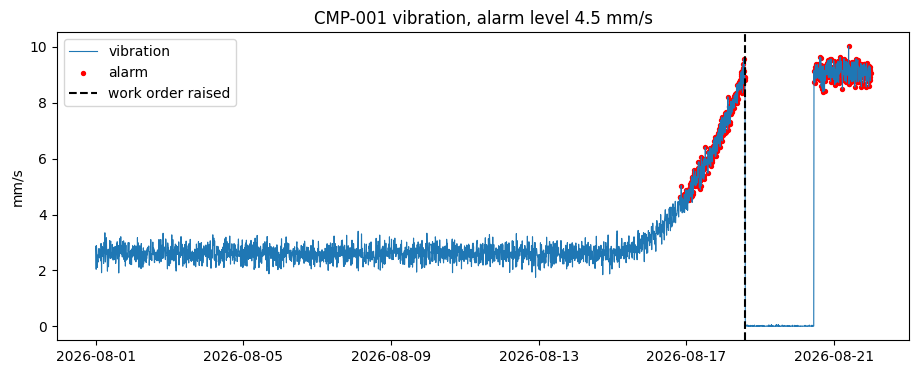

First alarm: 2026-08-16 19:40:00  ->  43 hours before the work order


In [17]:
flagged_low = add_flags(sens, alarm_level=4.5)
plot_cmp001(flagged_low, 4.5)

More warning, at the cost of more false alarms on other machines. Where to set it is an engineering decision. The
data's job is to make the evidence trustworthy, which is why removing the 9999 codes and spotting the stuck sensor
mattered: otherwise healthy machines would have raised alarms and nobody would trust the real one.

In [18]:
flagged.to_csv("outputs/sensor_readings_clean.csv", index=False)

## Recap
* Rules are True/False questions; True means a problem. Keep them together so you can count and report them.
* Errors are left out of the figures and sent back; warnings are reported.
* `assert` stops the run for whole-table problems.
* Sensor data: remove "no reading" codes, one unit per column, then flag stuck sensors and alarms separately.

**Optional, with Gemini:** ask *"What are the weaknesses of using one fixed vibration alarm level for different
machines?"* Did it state anything as fact that you would want to check in ISO 20816?

Next: **07 Packaging a Repeatable Script**.